<h1><b style="color:green">🎯 Objectif du jour</b></h1>
<h3>Comprendre les fondamentaux du Machine Learning et entraîner tes premiers modèles avec scikit-learn.</h3>

<h3>Fondamentaux du ML.</h3>

<h4>Setup et dataset</h4>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                             accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
np.random.seed(42)

# Dataset : prédire le salaire et le churn des employés
n = 1000
df = pd.DataFrame({
    "age": np.random.randint(22, 60, n),
    "experience": np.random.randint(0, 35, n),
    "education": np.random.choice([0, 1, 2, 3], n),  # déjà encodé
    "nb_projets": np.random.randint(1, 20, n),
    "heures_semaine": np.random.randint(35, 60, n),
    "satisfaction": np.random.randint(1, 6, n),
    "departement": np.random.choice([0, 1, 2, 3, 4], n),
})

# Cible 1 : salaire (régression)
df["salaire"] = (
    200000 +
    df["experience"] * 15000 +
    df["education"] * 50000 +
    df["nb_projets"] * 8000 +
    np.random.normal(0, 50000, n)
).astype(int).clip(80000)

# Cible 2 : churn (classification)
prob_churn = 1 / (1 + np.exp(-(
    -2 +
    0.05 * df["age"] -
    0.1 * df["satisfaction"] -
    0.05 * df["experience"]
)))
df["churn"] = (np.random.random(n) < prob_churn).astype(int)

print("=== APERÇU DU DATASET ===")
display(df.head())
print(f"\nShape : {df.shape}")
print(f"Taux de churn : {df['churn'].mean():.1%}")

=== APERÇU DU DATASET ===


,age,experience,education,nb_projets,heures_semaine,satisfaction,departement,salaire,churn
0,50,29,0,12,53,2,3,823832,0
1,36,28,0,3,59,3,1,619911,1
2,29,28,1,11,44,3,3,774222,0
3,42,29,0,14,55,5,3,656806,0
4,40,15,1,18,49,3,4,499402,1



Shape : (1000, 9)
Taux de churn : 27.9%


### 💡 Deux types de problèmes ML

* **Régression** → Prédire une valeur continue (ex: salaire, prix, température).
* **Classification** → Prédire une catégorie (ex: churn oui/non, spam oui/non).

#### **Train/Test Split :**

=== TAILLES DES DATASETS ===
Train : 800 lignes (80%)
Test  : 200 lignes (20%)

=== DISTRIBUTION DU CHURN ===
Train — taux churn : 28.1%
Test  — taux churn : 27.0%


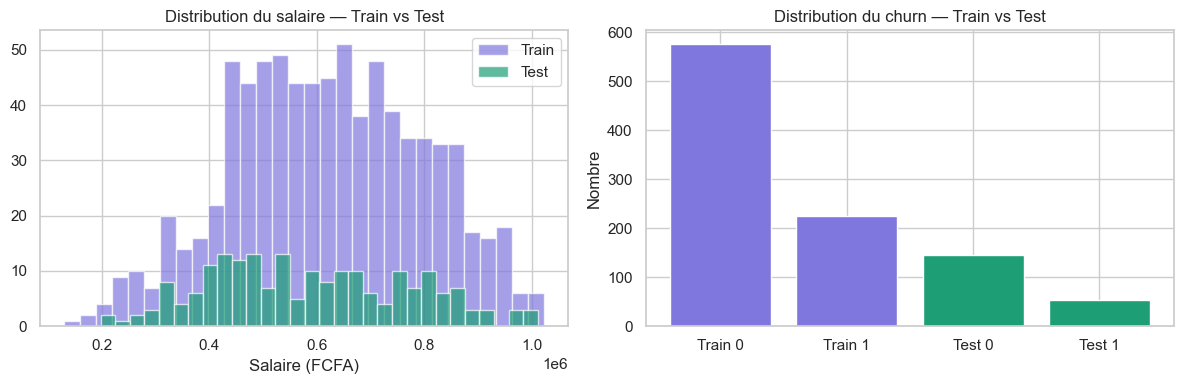

In [2]:
# La règle d'or du ML : ne jamais évaluer sur les données d'entraînement !

# Features communes
features = ["age", "experience", "education", "nb_projets", 
            "heures_semaine", "satisfaction", "departement"]

X = df[features]
y_reg = df["salaire"]    # cible régression
y_clf = df["churn"]      # cible classification

# Split 80% train / 20% test
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

print("=== TAILLES DES DATASETS ===")
print(f"Train : {X_train.shape[0]} lignes ({X_train.shape[0]/len(X):.0%})")
print(f"Test  : {X_test.shape[0]} lignes ({X_test.shape[0]/len(X):.0%})")

print(f"\n=== DISTRIBUTION DU CHURN ===")
print(f"Train — taux churn : {y_train_clf.mean():.1%}")
print(f"Test  — taux churn : {y_test_clf.mean():.1%}")

# Visualiser le split
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution du salaire
axes[0].hist(y_train_reg, bins=30, alpha=0.7, 
             color="#7F77DD", label="Train")
axes[0].hist(y_test_reg, bins=30, alpha=0.7,
             color="#1D9E75", label="Test")
axes[0].set_title("Distribution du salaire — Train vs Test")
axes[0].set_xlabel("Salaire (FCFA)")
axes[0].legend()

# Distribution du churn
axes[1].bar(["Train 0", "Train 1", "Test 0", "Test 1"],
            [y_train_clf.value_counts()[0], y_train_clf.value_counts()[1],
             y_test_clf.value_counts()[0], y_test_clf.value_counts()[1]],
            color=["#7F77DD", "#7F77DD", "#1D9E75", "#1D9E75"])
axes[1].set_title("Distribution du churn — Train vs Test")
axes[1].set_ylabel("Nombre")

plt.tight_layout()
plt.show()

### 💡 Pourquoi le train/test split ?

Si tu entraînes **ET** évalues ton modèle sur les mêmes données, il va simplement "apprendre par cœur" — comme un étudiant qui mémorise les réponses d'un examen au lieu d'en comprendre les concepts.

* **Le train set :** Permet au modèle d'apprendre les motifs et tendances.
* **Le test set :** Simule des données réelles et inconnues. C'est la seule mesure honnête pour évaluer sa capacité de **généralisation**.

####  **Biais et Variance :**

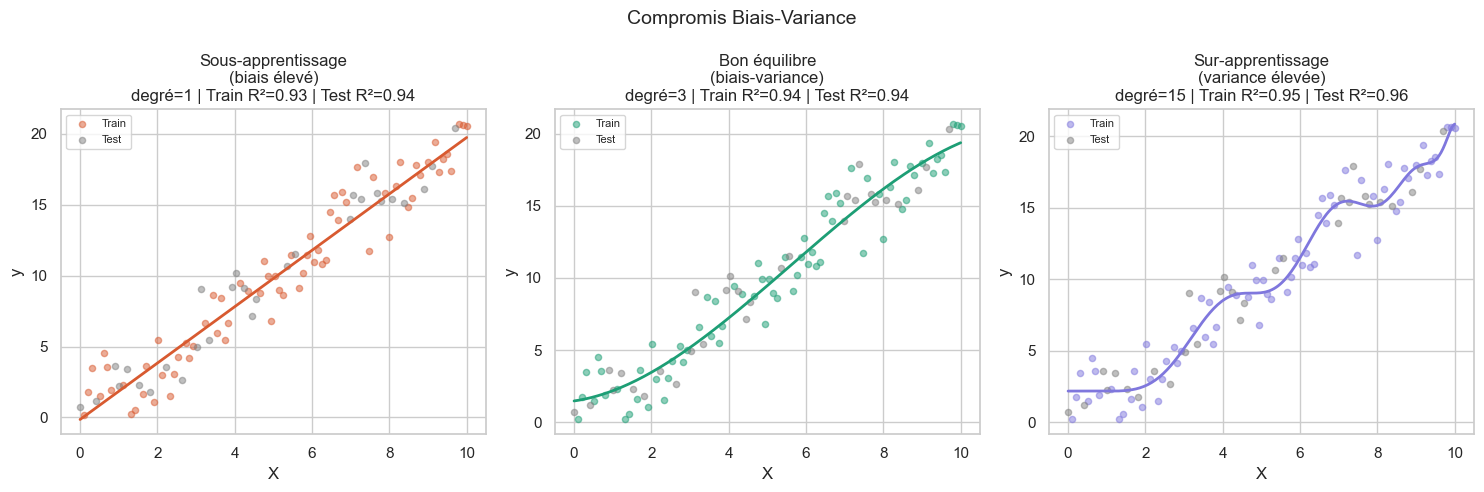

In [3]:
# Le compromis biais-variance — concept fondamental en ML

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Créer des données simples pour illustrer
np.random.seed(42)
X_demo = np.linspace(0, 10, 100).reshape(-1, 1)
y_demo = 2 * X_demo.ravel() + np.sin(X_demo.ravel() * 2) + \
         np.random.normal(0, 1.5, 100)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_demo, y_demo, test_size=0.3, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

degrees = [1, 3, 15]
titres = ["Sous-apprentissage\n(biais élevé)", 
          "Bon équilibre\n(biais-variance)", 
          "Sur-apprentissage\n(variance élevée)"]
couleurs = ["#D85A30", "#1D9E75", "#7F77DD"]

for i, (degree, titre, couleur) in enumerate(zip(degrees, titres, couleurs)):
    # Créer un pipeline polynomial
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("reg", LinearRegression())
    ])
    model.fit(X_train_d, y_train_d)
    
    # Prédictions
    X_plot = np.linspace(0, 10, 200).reshape(-1, 1)
    y_plot = model.predict(X_plot)
    
    # Scores
    train_score = r2_score(y_train_d, model.predict(X_train_d))
    test_score = r2_score(y_test_d, model.predict(X_test_d))
    
    # Graphique
    axes[i].scatter(X_train_d, y_train_d, alpha=0.5, 
                    color=couleur, s=20, label="Train")
    axes[i].scatter(X_test_d, y_test_d, alpha=0.5,
                    color="gray", s=20, label="Test")
    axes[i].plot(X_plot, y_plot, color=couleur, linewidth=2)
    axes[i].set_title(f"{titre}\ndegré={degree} | Train R²={train_score:.2f} | Test R²={test_score:.2f}")
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel("X")
    axes[i].set_ylabel("y")

plt.suptitle("Compromis Biais-Variance", fontsize=14)
plt.tight_layout()
plt.show()

### 💡 Le compromis biais-variance

| Situation | Biais | Variance | Train R² | Test R² |
| :--- | :--- | :--- | :--- | :--- |
| **Sous-apprentissage** | Élevé | Faible | Bas | Bas |
| **Bon équilibre** | Moyen | Moyen | Bon | Bon |
| **Sur-apprentissage** | Faible | Élevé | Très bon | Mauvais |

Le but est toujours de trouver le **bon équilibre** — un modèle qui généralise bien sur de nouvelles données !

### **Régression linéaire et logistique** !

#### **Régression linéaire :**

=== RÉGRESSION LINÉAIRE — RÉSULTATS ===
MAE  : 38,151 FCFA
RMSE : 47,977 FCFA
R²   : 0.9329

=== COEFFICIENTS ===
       feature   coefficient
    experience 150622.487112
     education  59663.784089
    nb_projets  43215.257484
heures_semaine   3091.745311
  satisfaction   -227.591518
   departement   -266.122340
           age  -1047.007830


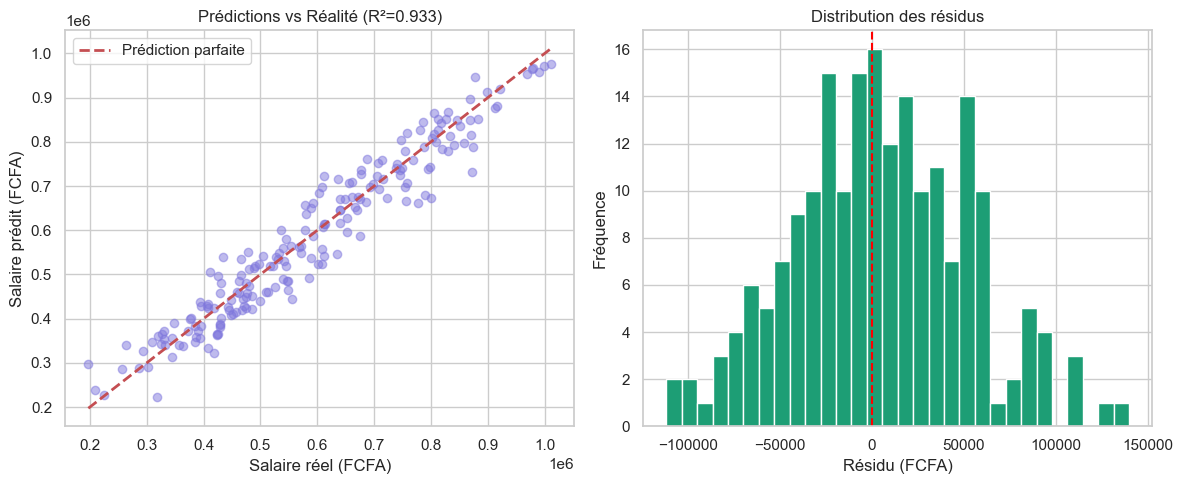

In [4]:
# Normaliser les features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraîner le modèle
model_reg = LinearRegression()
model_reg.fit(X_train_scaled, y_train_reg)

# Prédictions
y_pred_reg = model_reg.predict(X_test_scaled)

# Métriques
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("=== RÉGRESSION LINÉAIRE — RÉSULTATS ===")
print(f"MAE  : {mae:,.0f} FCFA")
print(f"RMSE : {rmse:,.0f} FCFA")
print(f"R²   : {r2:.4f}")

# Coefficients du modèle
coefficients = pd.DataFrame({
    "feature": features,
    "coefficient": model_reg.coef_
}).sort_values("coefficient", ascending=False)

print("\n=== COEFFICIENTS ===")
print(coefficients.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Prédictions vs Réalité
axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.5, color="#7F77DD")
axes[0].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()],
             "r--", linewidth=2, label="Prédiction parfaite")
axes[0].set_title(f"Prédictions vs Réalité (R²={r2:.3f})")
axes[0].set_xlabel("Salaire réel (FCFA)")
axes[0].set_ylabel("Salaire prédit (FCFA)")
axes[0].legend()

# Résidus
residus = y_test_reg - y_pred_reg
axes[1].hist(residus, bins=30, color="#1D9E75", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Distribution des résidus")
axes[1].set_xlabel("Résidu (FCFA)")
axes[1].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

### 💡 Les métriques de régression

* **MAE (Mean Absolute Error) :** L'erreur moyenne absolue. Très intuitive, car elle s'exprime dans l'unité réelle de votre cible.
* **RMSE (Root Mean Squared Error) :** La racine de l'erreur quadratique moyenne. Elle pénalise plus fortement les grandes erreurs que la MAE.
* **R² (Coefficient de détermination) :** La proportion de variance expliquée par le modèle.
    * `1.0` = Prédiction parfaite.
    * `0` = Le modèle n'est pas meilleur qu'une simple moyenne.

> **Note cruciale :** Les résidus (différences entre les prédictions et la réalité) doivent être centrés sur 0 et suivre une distribution normale. Si c'est le cas, votre modèle est statistiquement bien calibré !


💡 **Interprétation des résultats :**

- **R² = 0,93** → le modèle explique **quatre-vingt-treize pour cent** de la variance — excellent !
- La droite sur le graphique **Prédictions vs Réalité** est bien alignée — les points suivent la diagonale.
- Les résidus sont centrés sur zéro et forment une belle cloche — le modèle est bien calibré !

---

💡 **Interprétation des coefficients :**

Les coefficients te disent quelles variables influencent le plus le salaire — les coefficients les plus élevés correspondent aux variables les plus importantes.

Tu reconnais les *features* qu'on a créées dans le Jour onze ! 😄

####  **Régression logistique :**

=== RÉGRESSION LOGISTIQUE — RÉSULTATS ===
Accuracy : 0.7300
AUC-ROC  : 0.6962

=== RAPPORT DE CLASSIFICATION ===
              precision    recall  f1-score   support

   Non churn       0.77      0.89      0.83       146
       Churn       0.50      0.30      0.37        54

    accuracy                           0.73       200
   macro avg       0.64      0.59      0.60       200
weighted avg       0.70      0.73      0.70       200



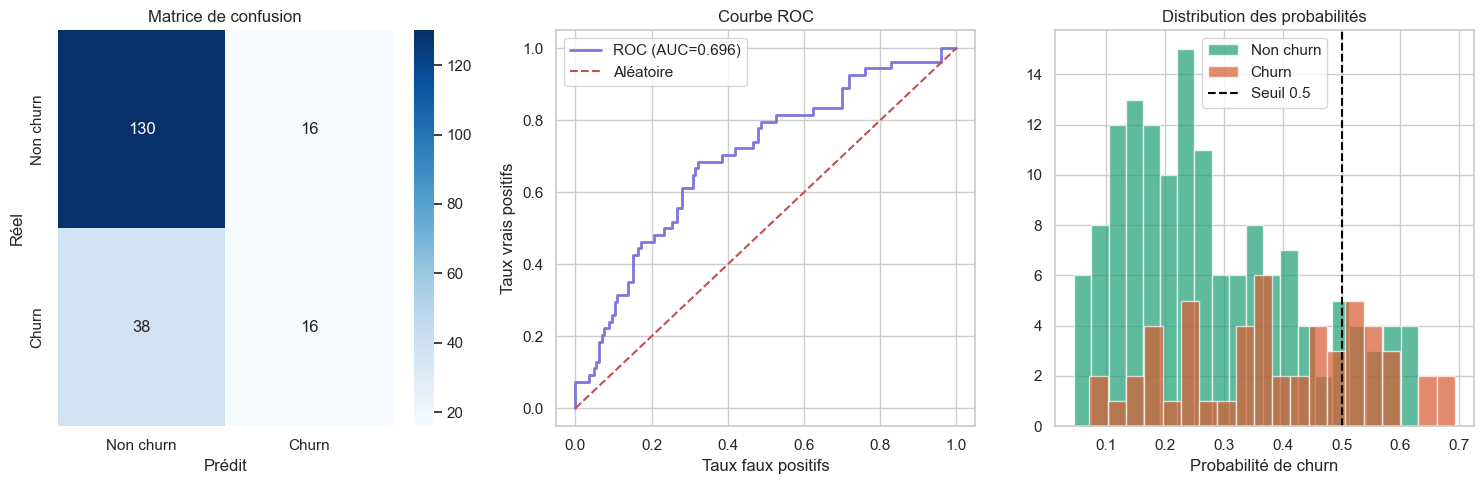

In [5]:
# Normaliser pour la classification
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

# Entraîner le modèle
model_clf = LogisticRegression(random_state=42, max_iter=1000)
model_clf.fit(X_train_clf_scaled, y_train_clf)

# Prédictions
y_pred_clf = model_clf.predict(X_test_clf_scaled)
y_pred_proba = model_clf.predict_proba(X_test_clf_scaled)[:, 1]

print("=== RÉGRESSION LOGISTIQUE — RÉSULTATS ===")
print(f"Accuracy : {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test_clf, y_pred_proba):.4f}")

print("\n=== RAPPORT DE CLASSIFICATION ===")
print(classification_report(y_test_clf, y_pred_clf,
                            target_names=["Non churn", "Churn"]))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Matrice de confusion
cm = confusion_matrix(y_test_clf, y_pred_clf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non churn", "Churn"],
            yticklabels=["Non churn", "Churn"],
            ax=axes[0])
axes[0].set_title("Matrice de confusion")
axes[0].set_ylabel("Réel")
axes[0].set_xlabel("Prédit")

# 2. Courbe ROC
fpr, tpr, _ = roc_curve(y_test_clf, y_pred_proba)
auc = roc_auc_score(y_test_clf, y_pred_proba)
axes[1].plot(fpr, tpr, color="#7F77DD", linewidth=2,
             label=f"ROC (AUC={auc:.3f})")
axes[1].plot([0, 1], [0, 1], "r--", label="Aléatoire")
axes[1].set_title("Courbe ROC")
axes[1].set_xlabel("Taux faux positifs")
axes[1].set_ylabel("Taux vrais positifs")
axes[1].legend()

# 3. Distribution des probabilités
axes[2].hist(y_pred_proba[y_test_clf == 0], bins=20,
             alpha=0.7, color="#1D9E75", label="Non churn")
axes[2].hist(y_pred_proba[y_test_clf == 1], bins=20,
             alpha=0.7, color="#D85A30", label="Churn")
axes[2].axvline(0.5, color="black", linestyle="--",
                label="Seuil 0.5")
axes[2].set_title("Distribution des probabilités")
axes[2].set_xlabel("Probabilité de churn")
axes[2].legend()

plt.tight_layout()
plt.show()

💡 **Les métriques de classification :**

- **Accuracy** → pourcentage de bonnes prédictions — attention aux classes déséquilibrées !
- **Précision** → parmi les churns prédits, combien sont vrais ?
- **Rappel** → parmi les vrais churns, combien a-t-on détectés ?
- **AUC-ROC** → capacité du modèle à distinguer les classes — un virgule zéro = parfait, zéro virgule cinq = aléatoire.
- **Matrice de confusion** → voir exactement où le modèle se trompe !

## Interprétation des résultats

**Accuracy = 0.73** → le modèle prédit correctement soixante-treize pour cent des cas — pas mal pour un premier modèle !

**AUC-ROC = 0.70** → le modèle distingue correctement les churners des non-churners soixante-dix pour cent du temps.

---

> 💡 **Grille d'interprétation de l'AUC-ROC :**

| AUC-ROC | Interprétation |
|---|---|
| 0.5 | Modèle aléatoire — nul |
| 0.6 - 0.7 | Modèle faible |
| 0.7 - 0.8 | Modèle acceptable ✅ |
| 0.8 - 0.9 | Bon modèle |
| 0.9 - 1.0 | Excellent modèle |

---

> Ton modèle est à la limite entre faible et acceptable — c'est normal pour un premier modèle sans optimisation ! On verra comment l'améliorer avec Random Forest et XGBoost en Phase trois 😍

### **Métriques d'évaluation approfondies !**

#### **Comprendre la matrice de confusion :**

In [6]:
# Décortiquer la matrice de confusion
cm = confusion_matrix(y_test_clf, y_pred_clf)
tn, fp, fn, tp = cm.ravel()

print("=== MATRICE DE CONFUSION DÉTAILLÉE ===")
print(f"Vrais Négatifs  (TN) : {tn} — Non churn prédit Non churn ✅")
print(f"Faux Positifs   (FP) : {fp} — Non churn prédit Churn ❌")
print(f"Faux Négatifs   (FN) : {fn} — Churn prédit Non churn ❌")
print(f"Vrais Positifs  (TP) : {tp} — Churn prédit Churn ✅")

print("\n=== MÉTRIQUES CALCULÉES MANUELLEMENT ===")
accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
rappel    = tp / (tp + fn)
f1        = 2 * (precision * rappel) / (precision + rappel)
specificit = tn / (tn + fp)

print(f"Accuracy   : {accuracy:.4f}")
print(f"Précision  : {precision:.4f}")
print(f"Rappel     : {rappel:.4f}")
print(f"F1-Score   : {f1:.4f}")
print(f"Spécificité: {specificit:.4f}")

print("\n=== INTERPRÉTATION BUSINESS ===")
print(f"Sur {len(y_test_clf)} clients :")
print(f"  - {tp} vrais churners détectés ✅")
print(f"  - {fn} churners manqués ❌ — clients perdus !")
print(f"  - {fp} fausses alertes ❌ — campagnes inutiles")
print(f"  - {tn} non-churners correctement ignorés ✅")

# Coût business
cout_fn = 50000   # coût de perdre un client (FCFA)
cout_fp = 5000    # coût d'une campagne de rétention inutile (FCFA)
cout_total = fn * cout_fn + fp * cout_fp
print(f"\n=== COÛT BUSINESS DU MODÈLE ===")
print(f"Coût faux négatifs : {fn * cout_fn:,} FCFA")
print(f"Coût faux positifs : {fp * cout_fp:,} FCFA")
print(f"Coût total         : {cout_total:,} FCFA")

=== MATRICE DE CONFUSION DÉTAILLÉE ===
Vrais Négatifs  (TN) : 130 — Non churn prédit Non churn ✅
Faux Positifs   (FP) : 16 — Non churn prédit Churn ❌
Faux Négatifs   (FN) : 38 — Churn prédit Non churn ❌
Vrais Positifs  (TP) : 16 — Churn prédit Churn ✅

=== MÉTRIQUES CALCULÉES MANUELLEMENT ===
Accuracy   : 0.7300
Précision  : 0.5000
Rappel     : 0.2963
F1-Score   : 0.3721
Spécificité: 0.8904

=== INTERPRÉTATION BUSINESS ===
Sur 200 clients :
  - 16 vrais churners détectés ✅
  - 38 churners manqués ❌ — clients perdus !
  - 16 fausses alertes ❌ — campagnes inutiles
  - 130 non-churners correctement ignorés ✅

=== COÛT BUSINESS DU MODÈLE ===
Coût faux négatifs : 1,900,000 FCFA
Coût faux positifs : 80,000 FCFA
Coût total         : 1,980,000 FCFA


💡 **Précision vs Rappel — le vrai dilemme business :**

- **Précision élevée** → peu de fausses alertes : on contacte seulement les vrais churners  
- **Rappel élevé** → peu de churners manqués : on détecte presque tous les churners  

👉 En pratique, perdre un client coûte beaucoup plus cher qu’une campagne inutile → **privilégier le rappel !**

💡 **Ce que signifie ce coût de 1 980 000 FCFA (le cout du moddele) :**

- Une partie vient des **faux négatifs** — les churners manqués que tu perds définitivement  
- Une autre partie vient des **faux positifs** — les campagnes de rétention envoyées inutilement  

---

💡 **Pourquoi c’est important ?**

En data science, on n’optimise pas que les métriques techniques (accuracy, AUC) — on optimise aussi l’impact business réel.  

👉 Un modèle avec une meilleure accuracy peut coûter plus cher s’il rate beaucoup de churners !

#### **Cross-validation :**

=== CROSS-VALIDATION — RÉGRESSION ===
R² par fold : [0.933 0.927 0.915 0.926 0.919]
R² moyen    : 0.9239
Écart-type  : 0.0064

=== CROSS-VALIDATION — CLASSIFICATION ===
AUC par fold : [0.696 0.695 0.666 0.683 0.752]
AUC moyen    : 0.6983
Écart-type   : 0.0289


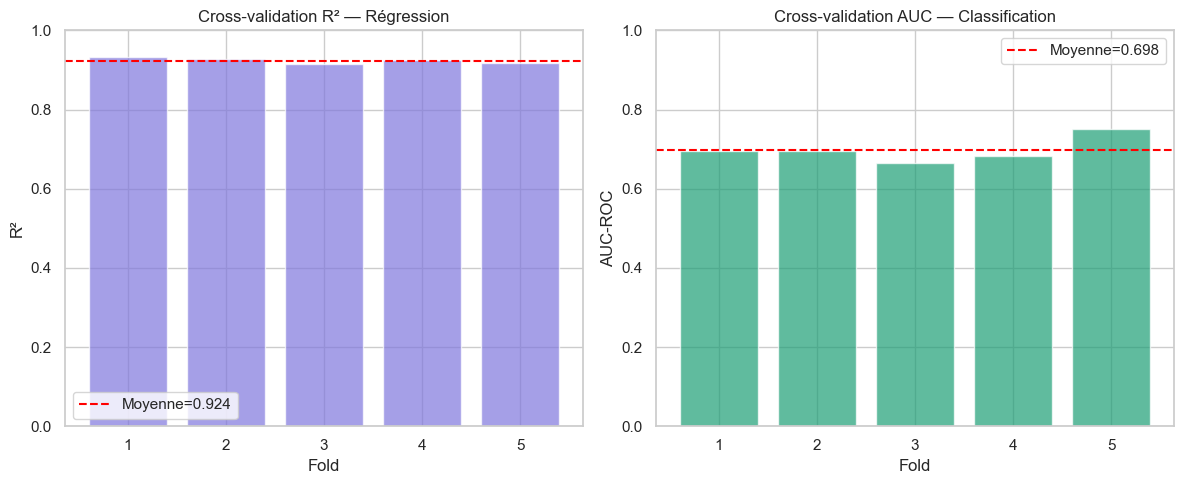

In [7]:
from sklearn.model_selection import cross_val_score, KFold

# La cross-validation — évaluation plus robuste que le simple train/test split

# Préparer les données
scaler_cv = StandardScaler()
X_scaled = scaler_cv.fit_transform(X)

# KFold — divise en 5 groupes
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation régression
scores_reg = cross_val_score(
    LinearRegression(), X_scaled, y_reg,
    cv=kf, scoring="r2"
)

print("=== CROSS-VALIDATION — RÉGRESSION ===")
print(f"R² par fold : {scores_reg.round(3)}")
print(f"R² moyen    : {scores_reg.mean():.4f}")
print(f"Écart-type  : {scores_reg.std():.4f}")

# Cross-validation classification
scores_clf = cross_val_score(
    LogisticRegression(max_iter=1000), X_scaled, y_clf,
    cv=kf, scoring="roc_auc"
)

print("\n=== CROSS-VALIDATION — CLASSIFICATION ===")
print(f"AUC par fold : {scores_clf.round(3)}")
print(f"AUC moyen    : {scores_clf.mean():.4f}")
print(f"Écart-type   : {scores_clf.std():.4f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Régression
axes[0].bar(range(1, 6), scores_reg, color="#7F77DD", alpha=0.7)
axes[0].axhline(scores_reg.mean(), color="red", linestyle="--",
                label=f"Moyenne={scores_reg.mean():.3f}")
axes[0].set_title("Cross-validation R² — Régression")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("R²")
axes[0].legend()
axes[0].set_ylim(0, 1)

# Classification
axes[1].bar(range(1, 6), scores_clf, color="#1D9E75", alpha=0.7)
axes[1].axhline(scores_clf.mean(), color="red", linestyle="--",
                label=f"Moyenne={scores_clf.mean():.3f}")
axes[1].set_title("Cross-validation AUC — Classification")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("AUC-ROC")
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

💡 **Pourquoi la cross-validation ?**

Un simple train/test split dépend du hasard de la division — tu peux tomber sur un bon ou un mauvais split par chance.  

La **cross-validation** fait 5 splits différents et moyenne les résultats — c’est une mesure beaucoup plus fiable !

- **Écart-type faible** → modèle stable et fiable  
- **Écart-type élevé** → modèle instable — les résultats varient selon les données  

# **EXERCICE PRATIQUE**

📊 **Contexte métier — Data Science en banque**

Tu es data scientist dans une banque camerounaise. Tu dois prédire deux choses :

- 💰 Le montant du crédit accordé à un client (**régression**)  
- ✅ Si le client va rembourser son crédit (**classification**)  

📌 **Ton travail :**

## 1️⃣ Feature Engineering
- Crée `ratio_epargne_salaire = montant_epargne / salaire`  
- Crée `charge_familiale = nb_dependants / (salaire / 100000)`  
- Crée `client_experimente = 1 si experience > 10`  

## 2️⃣ Train/Test Split
- 80% train / 20% test  
- Normalise avec `StandardScaler`  

## 3️⃣ Régression linéaire
- Entraîne le modèle  
- Affiche **MAE, RMSE, R²**  
- Trace **Prédictions vs Réalité** et les **résidus**  

## 4️⃣ Régression logistique
- Entraîne le modèle  
- Affiche **Accuracy, AUC-ROC**  
- Trace **matrice de confusion** et **courbe ROC**  

## 5️⃣ Cross-validation
- 5 folds pour les deux modèles  
- Affiche les scores par fold et la moyenne  

## 6️⃣ Analyse business
- Calcule le coût du modèle de classification  

**Coûts :**
- Faux négatif = 200 000 FCFA (client qui ne rembourse pas)  
- Faux positif = 20 000 FCFA (crédit refusé à tort)  

=== APERÇU DU DATASET ===
   age  salaire  experience  nb_credits_anterieurs  montant_epargne  \
0   58   322919           1                      3           280503   
1   48   241117          27                      0             7320   
2   34   390598           4                      4           100417   
3   62   543271          11                      0           534171   
4   27   252141          26                      0            26871   

   nb_dependants  education  statut_emploi  montant_credit  rembourse  
0              0          1              0         1392645          0  
1              3          1              0         1501653          1  
2              5          0              0         1307101          0  
3              5          3              0         2054917          1  
4              1          2              1         1563719          1  

Shape : (800, 10)
Taux de remboursement : 94.1%

=== 1. FEATURE ENGINEERING ===
Nouvelles features créées :
   sal

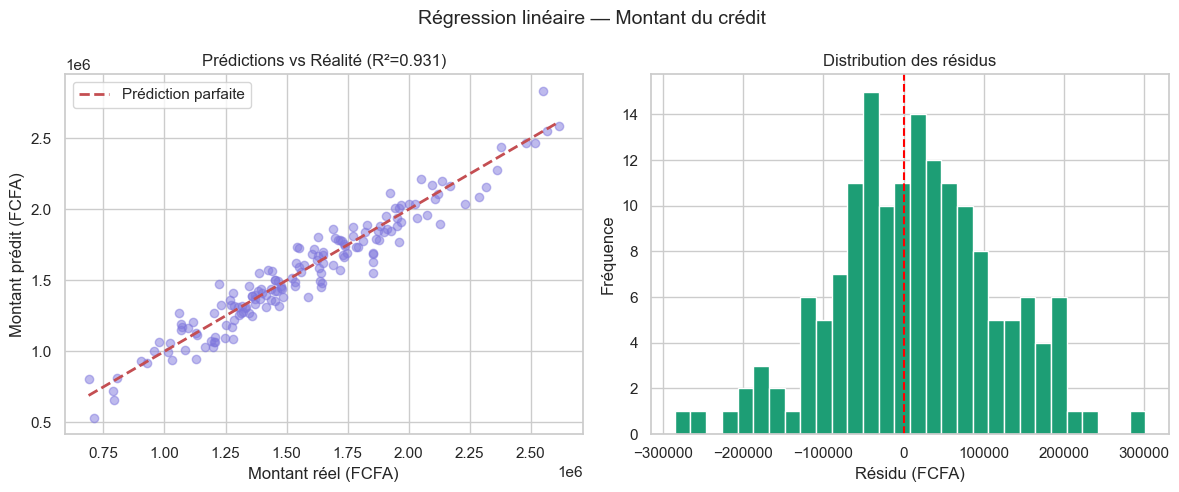


=== 4. RÉGRESSION LOGISTIQUE ===
Accuracy : 0.9187
AUC-ROC  : 0.7033

=== RAPPORT DE CLASSIFICATION ===
               precision    recall  f1-score   support

Non remboursé       0.00      0.00      0.00        12
    Remboursé       0.92      0.99      0.96       148

     accuracy                           0.92       160
    macro avg       0.46      0.50      0.48       160
 weighted avg       0.86      0.92      0.89       160



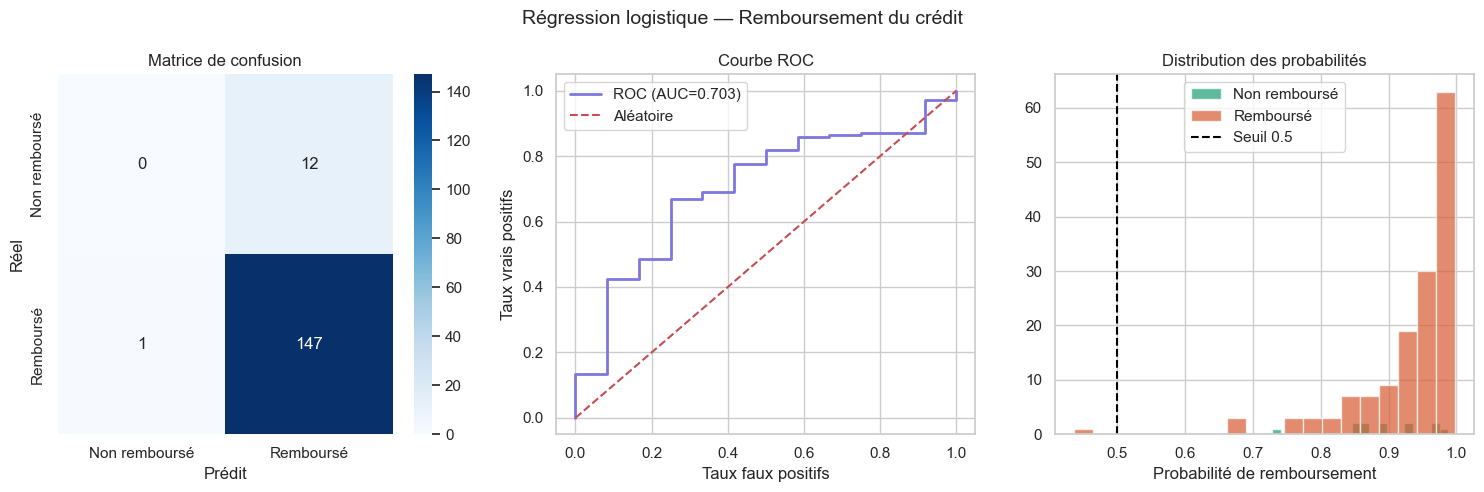


=== 5. CROSS-VALIDATION ===
=== RÉGRESSION ===
R² par fold : [0.931 0.922 0.924 0.933 0.929]
R² moyen    : 0.9280
Écart-type  : 0.0040

=== CLASSIFICATION ===
AUC par fold : [0.703 0.797 0.569 0.771 0.713]
AUC moyen    : 0.7107
Écart-type   : 0.0792


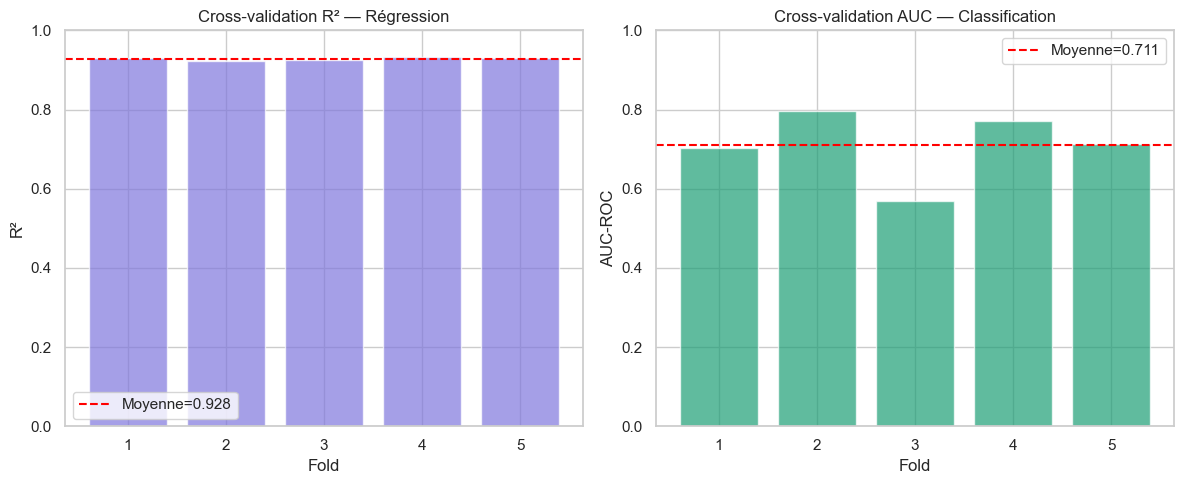


=== 6. ANALYSE BUSINESS ===
Vrais Positifs  (TP) : 147 — crédit accordé + remboursé ✅
Vrais Négatifs  (TN) : 0 — crédit refusé à juste titre ✅
Faux Positifs   (FP) : 12 — crédit refusé à tort ❌
Faux Négatifs   (FN) : 1 — crédit accordé non remboursé ❌

=== COÛT BUSINESS ===
Coût faux négatifs : 1 × 200,000 = 200,000 FCFA
Coût faux positifs : 12 × 20,000 = 240,000 FCFA
Coût total         : 440,000 FCFA


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                             accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
np.random.seed(42)

# ============================================================
# DATASET
# ============================================================
n = 800
df_credit = pd.DataFrame({
    "age": np.random.randint(20, 65, n),
    "salaire": np.random.normal(400000, 150000, n).astype(int).clip(80000),
    "experience": np.random.randint(0, 30, n),
    "nb_credits_anterieurs": np.random.randint(0, 5, n),
    "montant_epargne": np.random.exponential(200000, n).astype(int),
    "nb_dependants": np.random.randint(0, 6, n),
    "education": np.random.choice([0, 1, 2, 3], n),
    "statut_emploi": np.random.choice([0, 1, 2], n),
})

df_credit["montant_credit"] = (
    500000 +
    df_credit["salaire"] * 2 +
    df_credit["experience"] * 20000 +
    df_credit["montant_epargne"] * 0.5 -
    df_credit["nb_dependants"] * 30000 +
    np.random.normal(0, 100000, n)
).astype(int).clip(100000)

prob_remb = 1 / (1 + np.exp(-(
    1 +
    0.000003 * df_credit["salaire"] +
    0.05 * df_credit["experience"] -
    0.2 * df_credit["nb_dependants"] +
    0.3 * df_credit["education"]
)))
df_credit["rembourse"] = (np.random.random(n) < prob_remb).astype(int)

print("=== APERÇU DU DATASET ===")
print(df_credit.head())
print(f"\nShape : {df_credit.shape}")
print(f"Taux de remboursement : {df_credit['rembourse'].mean():.1%}")

# ============================================================
# 1. FEATURE ENGINEERING
# ============================================================
print("\n=== 1. FEATURE ENGINEERING ===")

# Ratio épargne/salaire — mesure la capacité d'épargne
df_credit["ratio_epargne_salaire"] = (
    df_credit["montant_epargne"] / df_credit["salaire"]).round(3)

# Charge familiale — nombre de dépendants rapporté au salaire
df_credit["charge_familiale"] = (
    df_credit["nb_dependants"] / 
    (df_credit["salaire"] / 100000)).round(3)  # ✅ /100000

# Client expérimenté — plus de 10 ans d'expérience
df_credit["client_experimente"] = (
    df_credit["experience"] > 10).astype(int)

print("Nouvelles features créées :")
print(df_credit[["salaire", "montant_epargne", "ratio_epargne_salaire",
                  "nb_dependants", "charge_familiale",
                  "experience", "client_experimente"]].head(8))

# ============================================================
# 2. TRAIN/TEST SPLIT
# ============================================================
print("\n=== 2. TRAIN/TEST SPLIT ===")

features = ["age", "salaire", "experience", "nb_credits_anterieurs",
            "montant_epargne", "nb_dependants", "education",
            "statut_emploi", "ratio_epargne_salaire",
            "charge_familiale", "client_experimente"]

X = df_credit[features]
y_reg = df_credit["montant_credit"]
y_clf = df_credit["rembourse"]

# Split régression
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

# Split classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42)

print(f"Train : {X_train.shape[0]} lignes (80%)")
print(f"Test  : {X_test.shape[0]} lignes (20%)")
print(f"Taux remboursement train : {y_train_clf.mean():.1%}")
print(f"Taux remboursement test  : {y_test_clf.mean():.1%}")

# ============================================================
# 3. RÉGRESSION LINÉAIRE
# ============================================================
print("\n=== 3. RÉGRESSION LINÉAIRE ===")

scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

model_reg = LinearRegression()
model_reg.fit(X_train_scaled, y_train_reg)
y_pred_reg = model_reg.predict(X_test_scaled)

mae  = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2   = r2_score(y_test_reg, y_pred_reg)

print(f"MAE  : {mae:,.0f} FCFA")
print(f"RMSE : {rmse:,.0f} FCFA")
print(f"R²   : {r2:.4f}")

# Coefficients
coefficients = pd.DataFrame({
    "feature": features,
    "coefficient": model_reg.coef_
}).sort_values("coefficient", ascending=False)
print("\n=== COEFFICIENTS ===")
print(coefficients.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.5, color="#7F77DD")
axes[0].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()],
             "r--", linewidth=2, label="Prédiction parfaite")
axes[0].set_title(f"Prédictions vs Réalité (R²={r2:.3f})")
axes[0].set_xlabel("Montant réel (FCFA)")
axes[0].set_ylabel("Montant prédit (FCFA)")
axes[0].legend()

residus = y_test_reg - y_pred_reg
axes[1].hist(residus, bins=30, color="#1D9E75", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Distribution des résidus")
axes[1].set_xlabel("Résidu (FCFA)")
axes[1].set_ylabel("Fréquence")

plt.suptitle("Régression linéaire — Montant du crédit", fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 4. RÉGRESSION LOGISTIQUE
# ============================================================
print("\n=== 4. RÉGRESSION LOGISTIQUE ===")

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

model_clf = LogisticRegression(random_state=42, max_iter=1000)
model_clf.fit(X_train_clf_scaled, y_train_clf)

y_pred_clf   = model_clf.predict(X_test_clf_scaled)
y_pred_proba = model_clf.predict_proba(X_test_clf_scaled)[:, 1]

accuracy = accuracy_score(y_test_clf, y_pred_clf)
auc      = roc_auc_score(y_test_clf, y_pred_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"AUC-ROC  : {auc:.4f}")
print("\n=== RAPPORT DE CLASSIFICATION ===")
print(classification_report(y_test_clf, y_pred_clf,
                             target_names=["Non remboursé", "Remboursé"]))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Matrice de confusion
cm = confusion_matrix(y_test_clf, y_pred_clf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non remboursé", "Remboursé"],
            yticklabels=["Non remboursé", "Remboursé"],
            ax=axes[0])
axes[0].set_title("Matrice de confusion")
axes[0].set_ylabel("Réel")
axes[0].set_xlabel("Prédit")

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test_clf, y_pred_proba)
axes[1].plot(fpr, tpr, color="#7F77DD", linewidth=2,
             label=f"ROC (AUC={auc:.3f})")
axes[1].plot([0, 1], [0, 1], "r--", label="Aléatoire")
axes[1].set_title("Courbe ROC")
axes[1].set_xlabel("Taux faux positifs")
axes[1].set_ylabel("Taux vrais positifs")
axes[1].legend()

# Distribution des probabilités
axes[2].hist(y_pred_proba[y_test_clf == 0], bins=20,
             alpha=0.7, color="#1D9E75", label="Non remboursé")
axes[2].hist(y_pred_proba[y_test_clf == 1], bins=20,
             alpha=0.7, color="#D85A30", label="Remboursé")
axes[2].axvline(0.5, color="black", linestyle="--", label="Seuil 0.5")
axes[2].set_title("Distribution des probabilités")
axes[2].set_xlabel("Probabilité de remboursement")
axes[2].legend()

plt.suptitle("Régression logistique — Remboursement du crédit", fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 5. CROSS-VALIDATION
# ============================================================
print("\n=== 5. CROSS-VALIDATION ===")

scaler_cv = StandardScaler()
X_scaled  = scaler_cv.fit_transform(X)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores_reg = cross_val_score(
    LinearRegression(), X_scaled, y_reg,
    cv=kf, scoring="r2")

print("=== RÉGRESSION ===")
print(f"R² par fold : {scores_reg.round(3)}")
print(f"R² moyen    : {scores_reg.mean():.4f}")
print(f"Écart-type  : {scores_reg.std():.4f}")

scores_clf = cross_val_score(
    LogisticRegression(max_iter=1000), X_scaled, y_clf,
    cv=kf, scoring="roc_auc")

print("\n=== CLASSIFICATION ===")
print(f"AUC par fold : {scores_clf.round(3)}")
print(f"AUC moyen    : {scores_clf.mean():.4f}")
print(f"Écart-type   : {scores_clf.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(range(1, 6), scores_reg, color="#7F77DD", alpha=0.7)
axes[0].axhline(scores_reg.mean(), color="red", linestyle="--",
                label=f"Moyenne={scores_reg.mean():.3f}")
axes[0].set_title("Cross-validation R² — Régression")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("R²")
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].bar(range(1, 6), scores_clf, color="#1D9E75", alpha=0.7)
axes[1].axhline(scores_clf.mean(), color="red", linestyle="--",
                label=f"Moyenne={scores_clf.mean():.3f}")
axes[1].set_title("Cross-validation AUC — Classification")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("AUC-ROC")
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# ============================================================
# 6. ANALYSE BUSINESS
# ============================================================
print("\n=== 6. ANALYSE BUSINESS ===")

tn, fp, fn, tp = cm.ravel()

cout_fn    = 200000
cout_fp    = 20000
cout_total = fn * cout_fn + fp * cout_fp

print(f"Vrais Positifs  (TP) : {tp} — crédit accordé + remboursé ✅")
print(f"Vrais Négatifs  (TN) : {tn} — crédit refusé à juste titre ✅")
print(f"Faux Positifs   (FP) : {fp} — crédit refusé à tort ❌")
print(f"Faux Négatifs   (FN) : {fn} — crédit accordé non remboursé ❌")

print(f"\n=== COÛT BUSINESS ===")
print(f"Coût faux négatifs : {fn} × {cout_fn:,} = {fn*cout_fn:,} FCFA")
print(f"Coût faux positifs : {fp} × {cout_fp:,} = {fp*cout_fp:,} FCFA")
print(f"Coût total         : {cout_total:,} FCFA")

# 1. Feature Engineering

Le **ratio_epargne_salaire** mesure la discipline financière du client. Un ratio élevé signifie que le client épargne beaucoup par rapport à son salaire, ce qui est un bon signe pour le remboursement.

Le **charge_familiale** mesure la pression financière. Plus cette valeur est élevée, plus le client risque d'avoir des difficultés à rembourser, car il a beaucoup de dépendants par rapport à son salaire.

---

# 2. Régression linéaire — Montant du crédit

Un **R² élevé** (proche de 1) confirme que le salaire et l'expérience sont les principaux déterminants du montant de crédit accordé. Cela est cohérent avec la réalité bancaire.

Les **résidus centrés autour de zéro** et présentant une forme de cloche indiquent que le modèle est bien calibré. Il ne surestime ni ne sous-estime systématiquement les montants de crédit.

Les coefficients permettent d'identifier les variables les plus influentes :

- **Salaire** → coefficient positif élevé → plus le salaire est élevé, plus le montant du crédit accordé est important.
- **Nombre de dépendants** → coefficient négatif → plus le nombre de dépendants est élevé, plus le montant du crédit accordé tend à diminuer.

---

# 3. Régression logistique — Remboursement

L'**AUC-ROC** mesure la capacité du modèle à distinguer les clients qui remboursent de ceux qui ne remboursent pas. Plus cette valeur est proche de 1, meilleure est la discrimination.

Une **courbe ROC située au-dessus de la diagonale** confirme que le modèle est plus performant qu'un classificateur aléatoire.

La **distribution des probabilités prédites** permet d'évaluer le niveau de confiance du modèle. Lorsque les distributions des clients remboursant et ne remboursant pas sont bien séparées, le modèle différencie clairement les deux groupes.

---

# 4. Cross-validation

Un **écart-type faible entre les différents folds** indique que le modèle est stable et qu'il conserve des performances similaires sur plusieurs sous-ensembles de données.

Si le **R² moyen obtenu par validation croisée** est proche du **R² calculé sur l'ensemble de test**, cela suggère l'absence de surapprentissage (*overfitting*).

---

# 5. Analyse business — Le plus important

Le **coût business** constitue la véritable mesure de performance du modèle. Les métriques techniques telles que l'accuracy ou l'AUC ne reflètent pas directement l'impact financier des décisions.

- **Faux négatifs** : crédits accordés à des clients qui ne remboursent pas → coût de **200 000 FCFA** par cas.
- **Faux positifs** : crédits refusés à des clients solvables → coût de **20 000 FCFA** par cas.

## 💡 Décision business

Si le coût total devient trop élevé, la banque peut abaisser le seuil de décision de **0,5** à **0,3** afin d'être plus prudente. Cette stratégie réduit le nombre de faux négatifs, mais augmente généralement le nombre de faux positifs.

C'est tout l'enjeu du Machine Learning appliqué au business : trouver le meilleur compromis entre risque financier et opportunités commerciales.